In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Procesamiento de dataframes de pelota y robots

En este notebook el objetivo es limpiar y configurar los datasets de pelota y robots, de tal forma que por cada frame exista a lo mucho uno solo de los siguientes elementos:

1. Pelota
2. Robot 10A
3. Robot 10B
4. Robot 17B

Asimismo, se busca asignar cada #ID a su robot real correspondiente, asi como eliminar aquellos #IDs con falsos positivos o que fueron segmentados incorrectamente.


---------------------------------
Una vez limpios ambos datasets, se creara uno mas (el final) el cual tenga las siguientes celdas adicionales

- Distancia entre la pelota y el robot 10A
- Distancia entre la pelota y el robot 10B
- Distancia entre la pelota y el robot 17B

Con lo anterior se podra verificar de una mejor manera que robot golpeo o intersecto la pelota en un momento dado.



#1. Exploracion de dataframes

In [ ]:
#1. IMPORTAR LOS DATAFRAMES

ruta_pelota = "/content/drive/MyDrive/PROYECTO SAM 3/datasets/pelota_video_completo/datosPelotaVideoCompleto.csv"
ruta_robots = "/content/drive/MyDrive/PROYECTO SAM 3/datasets/datos_robots_video_completo/v2-datos_robots_video_completo.csv"


df_pelota = pd.read_csv(ruta_pelota)
df_robots = pd.read_csv(ruta_robots)

In [ ]:
df_pelota.head()

,frame,tracker_id,class_name,x_canon,y_canon,num_detecciones,area_pixeles
0,1,NaN,NaN,NaN,NaN,0,NaN
1,2,NaN,NaN,NaN,NaN,0,NaN
2,3,-1.0,orange ball,90.625,263.25,1,70.0
3,4,NaN,NaN,NaN,NaN,0,NaN
4,5,-1.0,orange ball,90.375,262.00,1,90.5


In [ ]:
df_robots.head()

,frame,tracker_id,class_name,x_canon,y_canon,area_caja,area_mascara,ancho_caja,alto_caja
0,1,0,robot,89.750,53.750,18923.0,14931,127.0,149.0
1,1,1,robot,88.125,166.875,16714.0,13286,122.0,137.0
2,1,2,robot,87.875,79.875,16625.0,12901,125.0,133.0
3,2,0,robot,89.875,53.000,19737.0,15447,129.0,153.0
4,2,1,robot,87.875,166.250,17112.0,13751,124.0,138.0


In [ ]:
df_robots.describe()

,frame,tracker_id,x_canon,y_canon,area_caja,area_mascara,ancho_caja,alto_caja
count,43044.000000,43044.000000,43044.000000,43044.000000,4.304400e+04,4.304400e+04,43044.000000,43044.000000
mean,8846.140902,96.215872,93.523543,100.453626,1.256138e+05,5.549085e+04,184.667178,260.073111
std,5800.491558,76.844847,43.623392,70.684374,4.290807e+05,2.330468e+05,215.190081,377.533482
min,1.000000,0.000000,7.500000,-30.500000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,3865.000000,41.000000,58.000000,41.250000,1.806000e+04,1.297500e+04,126.000000,143.000000
50%,8062.500000,72.000000,91.000000,85.625000,2.232000e+04,1.615500e+04,134.000000,164.000000
75%,13925.000000,123.000000,124.875000,165.375000,2.834000e+04,1.901900e+04,147.000000,200.000000
max,19393.000000,327.000000,205.875000,279.000000,2.070601e+06,1.749323e+06,1079.000000,1919.000000


# 2 Exploracion y limpieza dataframe de pelota

El objetivo es que el dataframe tenga las siguientes columnas:

- frame
- tracker_id (-1 siempre o -2 porque luego ByteTrack usa -1)
- class_name
- x_canon
- y_canon
- velocidad (calculada con el frame anterior o el 5to anterior)

Ademas, debe haber una sola deteccion por frame

In [ ]:
df_pelota.describe()

,frame,tracker_id,x_canon,y_canon,num_detecciones,area_pixeles
count,20418.000000,15488.0,15488.000000,15488.000000,20418.000000,15488.000000
mean,9517.976295,-1.0,93.260581,117.372143,0.884905,442.316665
std,5634.752875,0.0,39.745552,79.632397,0.671108,211.867250
min,1.000000,-1.0,9.250000,-14.750000,0.000000,60.000000
25%,4627.250000,-1.0,57.375000,28.000000,1.000000,246.000000
50%,9403.500000,-1.0,90.000000,121.000000,1.000000,523.500000
75%,14404.750000,-1.0,127.875000,187.125000,1.000000,613.625000
max,19393.000000,-1.0,207.625000,280.000000,5.000000,849.500000


In [ ]:
df_pelota['frame'].value_counts().value_counts()

,count
count,
1,18579
2,650
3,124
4,33
5,7


### Eliminando las detecciones que se salen de los limites

In [ ]:
#Primero quitamos a los que se salen de los limites del campo

df_pelota_filtrado = df_pelota[df_pelota["x_canon"]<183 ].copy()
df_pelota_filtrado = df_pelota_filtrado[df_pelota_filtrado["y_canon"]>0 ]
df_pelota_filtrado = df_pelota_filtrado[df_pelota_filtrado["y_canon"]<244 ]

In [ ]:
#Cuantos frames hay en total
#Hay 14,278 frames = 476.25 segundos  = 7.93 minutos
#Hay 628 frames = 20.94 segundos con mas de una deteccion
df_pelota_filtrado["frame"].value_counts().value_counts()

,count
count,
1,13650
2,540
3,72
4,14
5,2


In [ ]:
df_pelota_filtrado.describe()

,frame,tracker_id,x_canon,y_canon,num_detecciones,area_pixeles
count,15012.000000,15012.0,15012.000000,15012.000000,15012.000000,15012.000000
mean,8931.379829,-1.0,92.995545,117.897549,1.139821,449.575373
std,5168.371845,0.0,39.433409,77.826282,0.469261,208.729327
min,61.000000,-1.0,10.625000,0.125000,1.000000,60.000000
25%,4653.750000,-1.0,56.500000,28.593750,1.000000,254.375000
50%,8901.500000,-1.0,90.125000,121.125000,1.000000,530.500000
75%,12856.250000,-1.0,127.875000,187.125000,1.000000,616.000000
max,19175.000000,-1.0,182.875000,243.750000,5.000000,849.500000


<Axes: title={'center': 'Cuantas veces se repiten los frames'}, ylabel='Frequency'>

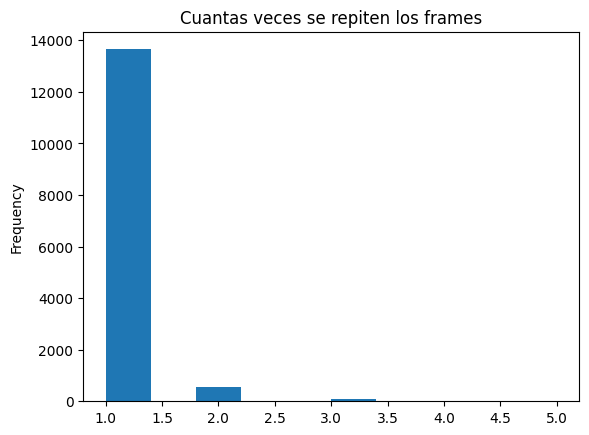

In [ ]:
df_pelota_filtrado["frame"].value_counts().plot.hist(title="Cuantas veces se repiten los frames")

<Axes: title={'center': 'Histograma de area de las detecciones'}, ylabel='Frequency'>

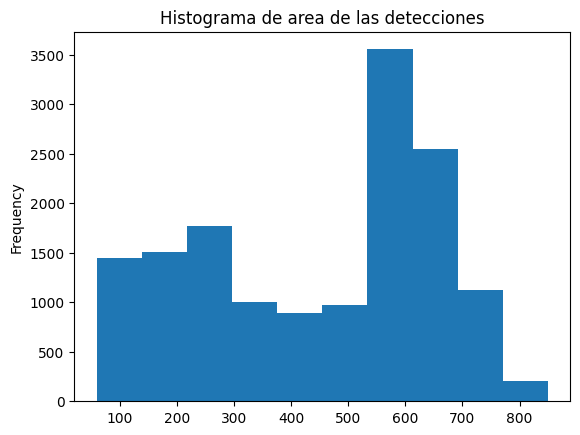

In [ ]:
df_pelota_filtrado["area_pixeles"].plot.hist(title='Histograma de area de las detecciones')

### Explorar el subconjunto con una deteccion o menos


In [ ]:
df_pelota_unicas = df_pelota_filtrado[df_pelota_filtrado["num_detecciones"]<2 ]
df_pelota_unicas.describe()

,frame,tracker_id,x_canon,y_canon,num_detecciones,area_pixeles
count,13479.000000,13479.0,13479.000000,13479.000000,13479.0,13479.000000
mean,9246.211885,-1.0,94.062625,123.039274,1.0,468.666073
std,5078.468740,0.0,40.104778,75.024643,0.0,196.869873
min,61.000000,-1.0,10.625000,0.125000,1.0,60.000000
25%,5162.500000,-1.0,53.000000,36.437500,1.0,273.000000
50%,9366.000000,-1.0,90.375000,121.625000,1.0,548.000000
75%,13026.500000,-1.0,129.250000,187.125000,1.0,620.500000
max,19175.000000,-1.0,179.375000,243.750000,1.0,849.500000


<Axes: title={'center': 'Histograma del area de frames donde solo hay una deteccion o menos'}, ylabel='Frequency'>

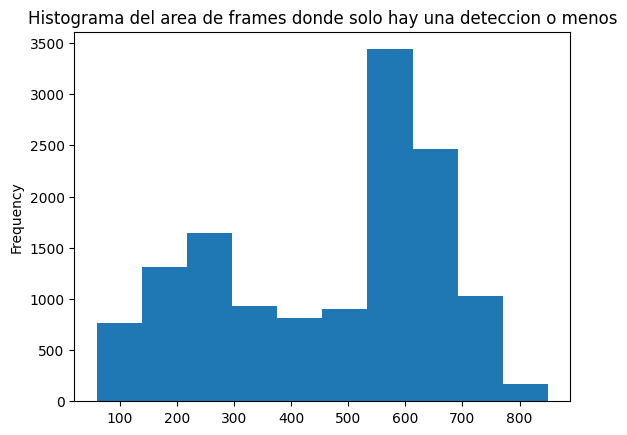

In [ ]:
df_pelota_unicas["area_pixeles"].plot.hist(title='Histograma del area de frames donde solo hay una deteccion o menos')

In [ ]:
#Cuantos frames diferentes hay en total?
df_pelota_unicas.shape

(13479, 7)

### Explorar el subconjunto con mas de una deteccion

In [ ]:
#Vamos a explorar aquellos que tienen mas de una deteccion
#Los que tienen 0 y 1 deteccion no seran eliminados. En las que hay 2 detecciones
#se estan contando dos veces, los de 3 se cuentan 3 veces.

df_pelota_multiples = df_pelota_filtrado[ df_pelota_filtrado['num_detecciones'] > 1]
df_pelota_multiples.describe()

,frame,tracker_id,x_canon,y_canon,num_detecciones,area_pixeles
count,1533.000000,1533.0,1533.000000,1533.000000,1533.000000,1533.000000
mean,6163.198956,-1.0,83.613177,72.688601,2.369211,281.719178
std,5127.786186,0.0,31.434285,86.893855,0.687935,233.482377
min,83.000000,-1.0,18.500000,0.125000,2.000000,60.000000
25%,3741.000000,-1.0,59.000000,7.875000,2.000000,87.000000
50%,4786.000000,-1.0,75.750000,15.125000,2.000000,172.000000
75%,8219.000000,-1.0,98.625000,182.125000,3.000000,472.500000
max,18325.000000,-1.0,182.875000,243.375000,5.000000,845.000000


In [ ]:
df_pelota_multiples["frame"].value_counts().describe()

,count
count,799.000000
mean,1.918648
std,0.624993
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,5.000000


<Axes: title={'center': 'Cuantas veces se repiten los frames'}, ylabel='Frequency'>

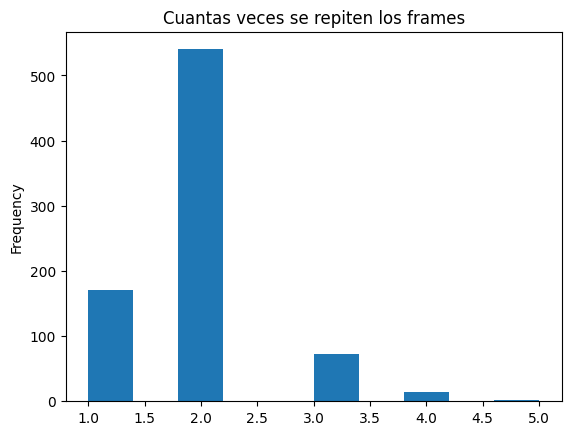

In [ ]:
df_pelota_multiples["frame"].value_counts().plot.hist(title="Cuantas veces se repiten los frames")

In [ ]:
df_pelota_multiples["frame"].value_counts().value_counts()

,count
count,
2,540
1,171
3,72
4,14
5,2


### Eliminamos aquellos que tengan mas de 1 apariciones,que vienen siendo alrededor de 20 segundos de video.

Debido a que es lo mejor considerando el tiempo disponible. Si me sobra tiempo pudiera realizar la deteccion de la pelota con SAM3 y realizar un proceso similar al de los robots.

In [ ]:
# 1. Calcular cuántas veces aparece cada frame
conteo = df_pelota_multiples['frame'].value_counts()

# 2. Identificar los frames que aparecen 1 veces o menos (excluyendo los que aparecen > 1)
frames_validos = conteo[conteo <= 1].index

# 3. Crear el nuevo dataframe filtrando por esos frames
df_multiples_limpio = df_pelota_multiples[df_pelota_multiples['frame'].isin(frames_validos)].copy()

In [ ]:
df_multiples_limpio.describe()

,frame,tracker_id,x_canon,y_canon,num_detecciones,area_pixeles
count,171.000000,171.0,171.000000,171.000000,171.000000,171.000000
mean,5760.970760,-1.0,81.747076,108.447368,2.146199,421.745614
std,5279.287048,0.0,28.405218,81.600263,0.386120,222.886422
min,83.000000,-1.0,18.750000,0.375000,2.000000,60.000000
25%,444.500000,-1.0,58.812500,24.000000,2.000000,213.250000
50%,5286.000000,-1.0,87.500000,120.875000,2.000000,468.000000
75%,8596.500000,-1.0,91.625000,178.687500,2.000000,608.250000
max,18324.000000,-1.0,166.000000,243.375000,4.000000,845.000000


### Combinamos df_pelota_unicas con df_multiples_limpio y nos quedamos con una sola deteccion por frame
Ok, creo que se esta haciendo un poco complicado limpiar los datos de la pelota, asi que mejor voy a eliminar tambien aquellos que tienen mas de una deteccion. Es la mejor opcion dado que tengo poco tiempo disponible. Y hara que el analisis sea mas sencillo.

In [ ]:
df_pelota_limpio = pd.concat([df_pelota_unicas,df_multiples_limpio],ignore_index=True).copy()
df_pelota_limpio.head()

,frame,tracker_id,class_name,x_canon,y_canon,num_detecciones,area_pixeles
0,61,-1.0,orange ball,85.875,186.625,1,95.0
1,66,-1.0,orange ball,84.500,183.250,1,82.5
2,68,-1.0,orange ball,84.750,180.375,1,97.0
3,74,-1.0,orange ball,83.375,173.375,1,103.5
4,75,-1.0,orange ball,84.125,172.375,1,83.5


### Quitamos las columnas que ya no nos sirven para el analisis de velocidad y posicion

In [ ]:
df_pelota_limpio=df_pelota_limpio.drop(columns=['num_detecciones','area_pixeles'])


In [ ]:
df_pelota_limpio

,frame,tracker_id,class_name,x_canon,y_canon
0,61,-1.0,orange ball,85.875,186.625
1,66,-1.0,orange ball,84.500,183.250
2,68,-1.0,orange ball,84.750,180.375
3,74,-1.0,orange ball,83.375,173.375
4,75,-1.0,orange ball,84.125,172.375
...,...,...,...,...,...
13645,17655,-1.0,orange ball,79.625,3.000
13646,17660,-1.0,orange ball,99.875,12.625
13647,18322,-1.0,orange ball,166.000,223.000
13648,18323,-1.0,orange ball,166.000,223.000


## Exploracion rapida del dataframe limpio de pelota

Se podria hacer una sustitucion de algunos valores faltantas con la media movil, solo que por el momento me lo saltare

<Axes: title={'center': 'Recorrido de la pelota a lo largo del partido'}, xlabel='y_canon', ylabel='x_canon'>

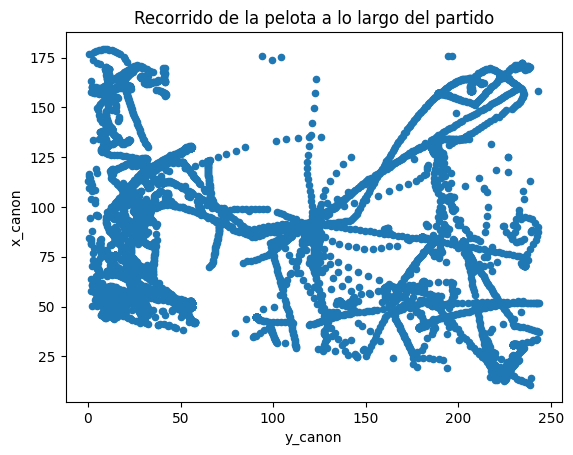

In [ ]:
df_pelota_limpio.plot.scatter(x='y_canon',y="x_canon",title="Recorrido de la pelota a lo largo del partido")

In [ ]:
#CALCULAR LA VELOCIDAD DE LA PELOTA CADA 15 FRAMES
# 1. Calculamos los desplazamientos (diferencia entre fila actual y anterior)
# .diff() calcula la resta entre la fila actual y la anterior
dx = df_pelota_limpio['x_canon'].diff(periods=15)
dy = df_pelota_limpio['y_canon'].diff(periods=15)
dframe = df_pelota_limpio['frame'].diff(periods=15)

# 2. Calculamos la distancia euclidiana
distancia = np.sqrt(dx**2 + dy**2)
# 3. Calculamos la velocidad (pixeles por frame)
df_pelota_limpio['velocidad_pelota'] = (distancia / dframe)*30 #Son 30FPS


In [ ]:
df_pelota_limpio.head(10)

,frame,tracker_id,class_name,x_canon,y_canon,velocidad_pelota
0,61,-1.0,orange ball,85.875,186.625,NaN
1,66,-1.0,orange ball,84.500,183.250,NaN
2,68,-1.0,orange ball,84.750,180.375,NaN
3,74,-1.0,orange ball,83.375,173.375,NaN
4,75,-1.0,orange ball,84.125,172.375,NaN
5,81,-1.0,orange ball,86.500,163.875,NaN
6,82,-1.0,orange ball,87.375,162.500,NaN
7,127,-1.0,orange ball,175.750,94.000,NaN
8,128,-1.0,orange ball,173.875,99.375,NaN
9,129,-1.0,orange ball,175.375,104.500,NaN


# 3. Exploracion y limpieza de dataframe de robots

Espero que esta de aqui sea un poco mas directa ya que tengo los IDs correspondientes a cada robot, los cuales asigne de forma manual. Con la filtracion de caracteristicas al crear el dataset de fotos los IDs defectuosos o falsos positivos se eliminaron automaticamente.

Solo para recordarlo, si ejecute el clustering con SigLIP ya que era mas sensible al color que DINOv3, pero aun asi el modelo no fue lo suficientemente practico.

Etiquetar de forma manual me tomo entre 2 y 3 horas en total.

Los IDs ordenados los tengo en una hoja de Google Spreadsheets, por el momento lo mas practico es copiar y pegarlos en una lista a cada uno.

## 3.1 Limpieza quitando datos que no deberian estar alli, como puntos negativos, areas muy grandes o ancho, alto desproporcionados


In [ ]:
#IDs asociadas a cada uno de los robots en el partido
robot_10a = [2,5,7,9,21,24,27,32,39,41,45,50,54,57,58,59,60,62,65,71,73,74,76,79,81,92,96,112,204,205,207,209,216]
robot_10b = [0,33,35,51,61,68,70,77,78,98,123,125,129,206,210,211]
robot_17b = [1,16,17,20,23,26,28,36,38,43,44,55,56,66,72,75,91,115,119,121,127,155,200,212,217]


#Primero vamos a crear una lista con todos los IDs que se encuentran en el dataframe
#luego vamos a eliminar todos aquellos que no se encuentren en la lista

ids_validos = robot_10a + robot_10b + robot_17b

df_robots_limpio = df_robots[df_robots['tracker_id'].isin(ids_validos)].copy()



In [ ]:
#Ahora vamos a asignar el robot correspondiente a cada una de las filas

# Mapeo de IDs a nombre de jugador
mapeo_jugadores = {
    **{id: '10a' for id in robot_10a},
    **{id: '10b' for id in robot_10b},
    **{id: '17b' for id in robot_17b}
}

#Vamos a usar el metodo .map de Pandas. El cual busca el tracker ID en el diccionario
#y asigna automaticamente el valor correspondiente

# Creamos la nueva columna 'jugador'
df_robots_limpio['jugador'] = df_robots_limpio['tracker_id'].map(mapeo_jugadores)

In [ ]:
df_robots_limpio.describe()

,frame,tracker_id,x_canon,y_canon,area_caja,area_mascara,ancho_caja,alto_caja
count,35337.000000,35337.000000,35337.000000,35337.000000,3.533700e+04,35337.000000,35337.000000,35337.000000
mean,8079.241588,83.847695,93.271896,96.861098,2.424265e+04,15273.970711,131.736367,170.468687
std,5356.597945,65.202997,42.266734,68.847437,4.023085e+04,5447.998850,44.562908,68.594838
min,1.000000,0.000000,11.000000,-30.500000,0.000000e+00,0.000000,0.000000,0.000000
25%,3667.000000,36.000000,58.250000,40.750000,1.812800e+04,13639.000000,126.000000,142.000000
50%,7286.000000,71.000000,90.875000,76.250000,2.197600e+04,16282.000000,133.000000,161.000000
75%,12421.000000,98.000000,128.250000,163.750000,2.589600e+04,18671.000000,143.000000,186.000000
max,18469.000000,217.000000,200.500000,269.125000,1.264146e+06,45040.000000,1042.000000,1597.000000


In [ ]:
#TAMBIEN VAMOS A QUITAR TODAS LAS DETECCIONES EN LAS QUE LAS PROYECCIONES SE
#SALEN DEL MAPA, PUES INDICAN QUE EL ROBOT FUE LEVANTADO O QUITADO DE LA CANCHA
df_robots_limpio = df_robots_limpio[df_robots_limpio['x_canon'] > 0]
df_robots_limpio = df_robots_limpio[df_robots_limpio['x_canon'] < 183]
df_robots_limpio = df_robots_limpio[df_robots_limpio['y_canon'] > 0]
df_robots_limpio = df_robots_limpio[df_robots_limpio['y_canon'] < 244]
pd.options.display.float_format = '{:.2f}'.format
df_robots_limpio.describe()

,frame,tracker_id,x_canon,y_canon,area_caja,area_mascara,ancho_caja,alto_caja
count,34976.00,34976.00,34976.00,34976.00,34976.00,34976.00,34976.00,34976.00
mean,8089.78,84.01,93.01,97.69,24226.41,15239.01,131.61,170.43
std,5352.38,65.20,42.23,68.28,40416.12,5364.72,44.57,67.76
min,1.00,0.00,11.00,0.12,0.00,0.00,0.00,0.00
25%,3688.75,36.00,57.50,41.12,18144.00,13646.75,126.00,142.00
50%,7286.00,71.00,90.75,77.75,21945.00,16266.00,133.00,161.00
75%,12436.25,98.00,128.12,164.00,25785.00,18639.25,143.00,185.00
max,18460.00,217.00,181.38,243.12,1264146.00,45040.00,1042.00,1597.00


In [ ]:
#VAMOS A QUITAR AQUELLAS QUE TENGAN MEDIDAS DE ANCHO,ALTO DEMASIDO GRANDES
#Por ejemplo, hay algunas que miden casi lo mismo que el frame
df_robots_limpio = df_robots_limpio[df_robots_limpio['ancho_caja'] < 270] #270 = 1080/4 = un cuarto del ancho
df_robots_limpio = df_robots_limpio[df_robots_limpio['alto_caja'] < 480] #480 = 1920/4 = un cuarto del alto
df_robots_limpio = df_robots_limpio[df_robots_limpio['area_caja'] > 100]   #Quitar los que tienen menos de 100 pixeles de area de caja
df_robots_limpio = df_robots_limpio[df_robots_limpio['area_mascara'] > 100] #Quitar los que tienen menos de 100 pixeles de area de mascara
#pd.options.display.float_format = '{:.2f}'.format

#Ordenamos por frame
df_robots_limpio.sort_values("frame")
df_robots_limpio.describe()

,frame,tracker_id,x_canon,y_canon,area_caja,area_mascara,ancho_caja,alto_caja
count,33798.00,33798.00,33798.00,33798.00,33798.00,33798.00,33798.00,33798.00
mean,8089.32,83.70,93.12,97.20,21965.87,15695.84,129.65,166.08
std,5333.27,64.89,41.98,68.22,7233.22,4648.71,27.73,34.93
min,1.00,0.00,11.00,0.12,114.00,101.00,3.00,28.00
25%,3738.00,38.00,58.50,41.25,18176.00,13845.00,126.00,143.00
50%,7355.00,72.00,90.75,76.25,21922.00,16388.00,133.00,161.00
75%,12290.75,98.00,127.88,163.75,25650.00,18695.75,142.00,184.00
max,18460.00,217.00,181.38,243.12,114453.00,37720.00,269.00,471.00


## Visualizacion de las areas de mascara y su importancia

Datos de este tipo pueden ayudar a ver como SAM 3 se desempena antes y despues de prompts positivos y negativos, como se desempena en diferentes contextos o videos. Analizar los mejores prompts para videos, y en pocas palabras, analizar el rendimiento de SAM 3. Si se dispone de suficiente poder computacional.

Este enfoque tambien puede ser usado para otras areas una vez que se haya hecho un refinamiento en areas especializadas. Por ejemplo, observar como cambia el tamano de microorganismos a lo largo del tiempo. En areas como biologia y conservacion de especies: estimar el tamano de animales o edad en funcion de la cantidad de pixeles y la distancia a la que se encuentra.

Tambien podria servir para estimar a que distancia se encontraba un objeto si ya se sabe de antemano sus medidas, usando el area de pixeles de la segmentacion.

Eventualmente se puede ajustar todo esto para que pueda ser aplicado a tiempo real.



<Axes: title={'center': 'Area de mascara de segmentacion en pixeles de robots'}, ylabel='Frequency'>

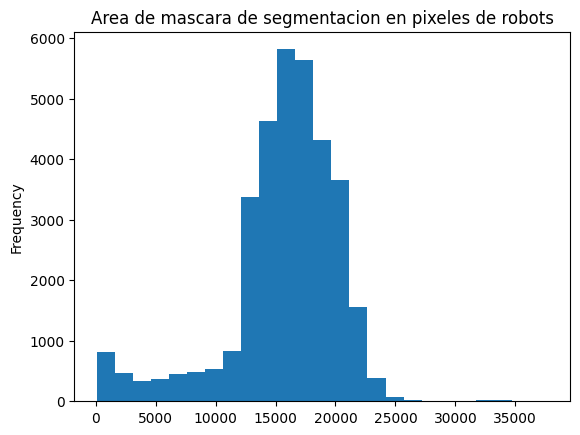

In [ ]:
df_robots_limpio['area_mascara'].plot.hist(bins=25,title="Area de mascara de segmentacion en pixeles de robots")

## 3.2 Crear un datafrmae para cada robot y calcular su velocidad y aceleracion

In [ ]:
#CREAR UN DATAFRAME PARA CADA ROBOT Y CALCULAR SU VELOCIDAD Y ACELERACION
df_robot_10a = df_robots_limpio[ df_robots_limpio['jugador'] == '10a' ].copy()
df_robot_10b = df_robots_limpio[ df_robots_limpio['jugador'] == '10b' ].copy()
df_robot_17b = df_robots_limpio[ df_robots_limpio['jugador'] == '17b' ].copy()


In [ ]:
df_robot_10b.head(10)

,frame,tracker_id,class_name,x_canon,y_canon,area_caja,area_mascara,ancho_caja,alto_caja,jugador
0,1,0,robot,89.75,53.75,18923.00,14931,127.00,149.00,10b
3,2,0,robot,89.88,53.00,19737.00,15447,129.00,153.00,10b
6,3,0,robot,89.75,52.62,19737.00,15433,129.00,153.00,10b
9,4,0,robot,89.75,52.00,20280.00,15661,130.00,156.00,10b
12,5,0,robot,89.75,51.62,20410.00,15734,130.00,157.00,10b
15,6,0,robot,89.50,51.25,20253.00,15707,129.00,157.00,10b
18,7,0,robot,89.38,50.62,20410.00,15930,130.00,157.00,10b
21,8,0,robot,89.38,50.12,20436.00,15837,131.00,156.00,10b
24,9,0,robot,89.38,49.50,20280.00,15943,130.00,156.00,10b
27,10,0,robot,89.38,49.12,20567.00,16018,131.00,157.00,10b


## 3.3 Calcular la velocidad de cada robot y eliminar columnas que ya no se usaran

In [ ]:
# ROBOT 10a --------------------------------------------------------------------
# 1. Calculamos los desplazamientos (diferencia entre fila actual y anterior)
# .diff() calcula la resta entre la fila actual y la anterior
dx = df_robot_10a['x_canon'].diff(periods=15)
dy = df_robot_10a['y_canon'].diff(periods=15)
dframe = df_robot_10a['frame'].diff(periods=15)

# 2. Calculamos la distancia euclidiana
distancia = np.sqrt(dx**2 + dy**2)
# 3. Calculamos la velocidad (pixeles por frame)
df_robot_10a['velocidad_10a'] = (distancia / dframe)*30 #Son 30FPS

# ROBOT 10B --------------------------------------------------------------------
# 1. Calculamos los desplazamientos (diferencia entre fila actual y anterior)
# .diff() calcula la resta entre la fila actual y la anterior
dx = df_robot_10b['x_canon'].diff(periods=15)
dy = df_robot_10b['y_canon'].diff(periods=15)
dframe = df_robot_10b['frame'].diff(periods=15)

# 2. Calculamos la distancia euclidiana
distancia = np.sqrt(dx**2 + dy**2)
# 3. Calculamos la velocidad (pixeles por frame)
df_robot_10b['velocidad_10b'] = (distancia / dframe)*30 #Son 30FPS


# ROBOT 17B --------------------------------------------------------------------
# 1. Calculamos los desplazamientos (diferencia entre fila actual y anterior)
# .diff() calcula la resta entre la fila actual y la anterior
dx = df_robot_17b['x_canon'].diff(periods=15)
dy = df_robot_17b['y_canon'].diff(periods=15)
dframe = df_robot_17b['frame'].diff(periods=15)

# 2. Calculamos la distancia euclidiana
distancia = np.sqrt(dx**2 + dy**2)

# 3. Calculamos la velocidad (pixeles por frame)
df_robot_17b['velocidad_17b'] = (distancia / dframe)*30 #Son 30FPS


#AHORA VAMOS A QUITAR COLUMNAS DE CADA DATAFRAME

df_robot_10a=df_robot_10a.drop(columns=['area_caja','area_mascara','ancho_caja','alto_caja'])
df_robot_10b=df_robot_10b.drop(columns=['area_caja','area_mascara','ancho_caja','alto_caja'])
df_robot_17b=df_robot_17b.drop(columns=['area_caja','area_mascara','ancho_caja','alto_caja'])


In [ ]:
df_robot_10a.describe()

,frame,tracker_id,x_canon,y_canon,velocidad_10a
count,12493.00,12493.00,12493.00,12493.00,12478.00
mean,9069.10,94.99,78.68,129.11,27.92
std,5572.99,68.86,43.41,59.82,23.73
min,1.00,2.00,11.00,0.12,0.00
25%,4290.00,54.00,35.25,79.00,12.87
50%,9483.00,81.00,82.88,124.38,31.77
75%,12617.00,112.00,109.62,180.25,40.08
max,18460.00,216.00,166.88,239.00,750.86


In [ ]:
df_robot_10a.head()

,frame,tracker_id,class_name,x_canon,y_canon,jugador,velocidad_10a
2,1,2,robot,87.88,79.88,10a,NaN
5,2,2,robot,87.88,79.50,10a,NaN
8,3,2,robot,87.88,79.12,10a,NaN
11,4,2,robot,87.88,78.62,10a,NaN
14,5,2,robot,87.62,78.12,10a,NaN


## 3.3 Calcular las distancias de cada robot a la pelota.

En estos calculos tambien tuve ayuda de Gemini, ya que olvide muchas de las funciones de la libreria de pandas y matpplotlib. Debo mencionar que los Modelos de Lenguaje pueden ser utiles en casos en los que metaforicamente debes crear otras instancias de ti mismo cuando eres un equipo de una sola persona. Siempre prefiero tratar de resolver los problemas o algoritmos por mi cuenta viendo la documentacion y copiando linea por linea.

De hecho imprimi cheatsheets de pandas para poder ver las cosas que necesito, pero el aprendizaje a profundidad que se requiere toma tiempo.

Esta es una situacion excepcional ya que aun tengo mucho trabajo por hacer y el tiempo me apremia.

No estoy diciendo que no pueda crear los dataframes ni graficos por mi cuenta, mas bien carezco del tiempo para poder aprender y descubrir como hacerlo.



In [ ]:
#-----------ROBOT 10A-----------------------------------------------------------
# 1. Creamos un DataFrame temporal cruzando el robot con la pelota por el 'frame'
# Solo traemos las coordenadas necesarias de la pelota para no duplicar datos
df_temporal = pd.merge(
    df_robot_10a[["frame", "x_canon", "y_canon"]],
    df_pelota_limpio[["frame", "x_canon", "y_canon"]],
    on="frame",
    how="left",
    suffixes=("_robot", "_pelota"),
)

# 2. Calculamos la distancia euclidiana usando la fórmula matemática y la asignamos directamente
df_robot_10a["distancia_pelota_10a"] = np.sqrt(
    (df_temporal["x_canon_robot"] - df_temporal["x_canon_pelota"]) ** 2
    + (df_temporal["y_canon_robot"] - df_temporal["y_canon_pelota"]) ** 2
)

In [ ]:
#-----------ROBOT 10B-----------------------------------------------------------
# 1. Creamos un DataFrame temporal cruzando el robot con la pelota por el 'frame'
# Solo traemos las coordenadas necesarias de la pelota para no duplicar datos
df_temporal = pd.merge(
    df_robot_10b[["frame", "x_canon", "y_canon"]],
    df_pelota_limpio[["frame", "x_canon", "y_canon"]],
    on="frame",
    how="left",
    suffixes=("_robot", "_pelota"),
)

# 2. Calculamos la distancia euclidiana usando la fórmula matemática y la asignamos directamente
df_robot_10b["distancia_pelota_10b"] = np.sqrt(
    (df_temporal["x_canon_robot"] - df_temporal["x_canon_pelota"]) ** 2
    + (df_temporal["y_canon_robot"] - df_temporal["y_canon_pelota"]) ** 2
)

In [ ]:
#-----------ROBOT 17B-----------------------------------------------------------
# 1. Creamos un DataFrame temporal cruzando el robot con la pelota por el 'frame'
# Solo traemos las coordenadas necesarias de la pelota para no duplicar datos
df_temporal = pd.merge(
    df_robot_17b[["frame", "x_canon", "y_canon"]],
    df_pelota_limpio[["frame", "x_canon", "y_canon"]],
    on="frame",
    how="left",
    suffixes=("_robot", "_pelota"),
)

# 2. Calculamos la distancia euclidiana usando la fórmula matemática y la asignamos directamente
df_robot_17b["distancia_pelota_17b"] = np.sqrt(
    (df_temporal["x_canon_robot"] - df_temporal["x_canon_pelota"]) ** 2
    + (df_temporal["y_canon_robot"] - df_temporal["y_canon_pelota"]) ** 2
)

### Verificar con histogramas que los datos se hayan creado correctamente

**NOTA IMPORTANTE:** Las distancias que se muestran aqui se calcularon con los frames en los que tanto el robot como la pelota se detectaron, no necesariamente representa las distancias durante todo el partido. Puede haber sobre-representacion. Por ejemplo, solamente existen la siguiente cantidad de registros para cada robot

|           | Frames en los que se tiene  distancia hacia pelota | Frames en los que aparece en video |   |   |
|-----------|---------------------------------------------------|------------------------------------|---|---|
| Robot 10A | 2236                                              | 12493                              |   |   |
| Robot 10B | 1242                                              | 9325                               |   |   |
| Robot 17B | 2997                                              | 11980                              |   |   |

OTRO PUNTO IMPORTANTE: Aun no se ha considerado el radio de cada robot ni de la pelota en el calculo de la distancia, ya que estos calculos se hicieron tomando como referencia el centro geometrico de la caja delimitadora de cada deteccion.

OTRA NOTA IMPORTANTE: Muchos de los datos faltantes pueden deberse a que la camara no capto la totalidad de la cancha. El analisis hubiera sido mas rico se se hubiera tenido la perspetiva de toda la cancha, incluso si hubiera sido una perspectiva oblicua y no cenital. Tambien puede deberse a que los robots no estuvieron la misma cantidad de tiempo dentro del juego, pues eran retirados a decision del juez o cuando entraban en la zona de penalty.

<Axes: title={'center': 'Histograma de distancia (cm) de 10A a la pelota a lo largo del partido'}, ylabel='Frequency'>

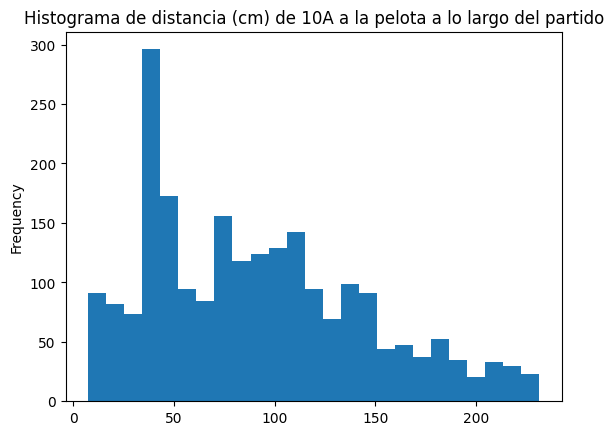

In [ ]:
df_robot_10a['distancia_pelota_10a'].plot.hist(title="Histograma de distancia (cm) de 10A a la pelota a lo largo del partido",bins=25)

<Axes: title={'center': 'Histograma de distancia (cm) de 10B a la pelota a lo largo del partido'}, ylabel='Frequency'>

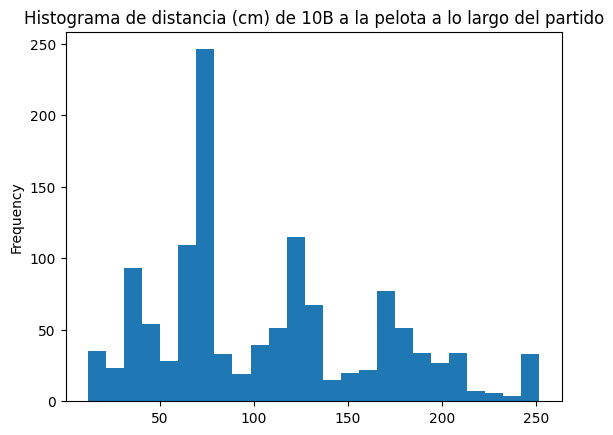

In [ ]:
df_robot_10b['distancia_pelota_10b'].plot.hist(title="Histograma de distancia (cm) de 10B a la pelota a lo largo del partido",bins=25)

<Axes: title={'center': 'Histograma de distancia (cm) de 17B a la pelota a lo largo del partido'}, ylabel='Frequency'>

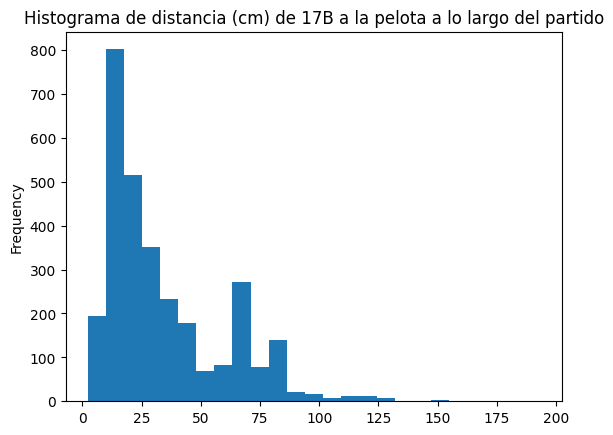

In [ ]:
df_robot_17b['distancia_pelota_17b'].plot.hist(title="Histograma de distancia (cm) de 17B a la pelota a lo largo del partido",bins=25)

In [ ]:
df_robot_10a['distancia_pelota_10a'].describe()

,distancia_pelota_10a
count,2236.00
mean,91.00
std,53.60
min,7.49
25%,44.03
50%,83.54
75%,125.94
max,231.30


In [ ]:
df_robot_10b['distancia_pelota_10b'].describe()

,distancia_pelota_10b
count,1242.00
mean,106.96
std,57.70
min,12.04
25%,68.88
50%,89.18
75%,148.45
max,251.53


In [ ]:
df_robot_17b['distancia_pelota_17b'].describe()

,distancia_pelota_17b
count,2997.00
mean,34.57
std,25.06
min,2.47
25%,15.29
50%,25.08
75%,46.19
max,192.84


In [ ]:
df_robot_17b.head()

,frame,tracker_id,class_name,x_canon,y_canon,jugador,velocidad_17b,distancia_pelota_17b
1,1,1,robot,88.12,166.88,17b,NaN,NaN
4,2,1,robot,87.88,166.25,17b,NaN,NaN
7,3,1,robot,87.75,165.88,17b,NaN,NaN
10,4,1,robot,87.50,165.62,17b,NaN,NaN
13,5,1,robot,87.38,165.25,17b,NaN,NaN


In [ ]:
df_pelota_limpio

,frame,tracker_id,class_name,x_canon,y_canon,velocidad_pelota
0,61,-1.00,orange ball,85.88,186.62,NaN
1,66,-1.00,orange ball,84.50,183.25,NaN
2,68,-1.00,orange ball,84.75,180.38,NaN
3,74,-1.00,orange ball,83.38,173.38,NaN
4,75,-1.00,orange ball,84.12,172.38,NaN
...,...,...,...,...,...,...
13645,17655,-1.00,orange ball,79.62,3.00,0.61
13646,17660,-1.00,orange ball,99.88,12.62,0.45
13647,18322,-1.00,orange ball,166.00,223.00,1.35
13648,18323,-1.00,orange ball,166.00,223.00,1.67


### Combinar las distancias a la pelota de cada robot (y velocidad) con el dataframe de la pelota misma.

In [ ]:
# Unimos la columna deseada basándonos en el 'frame'
df_pelota_limpio = df_pelota_limpio.merge(
    df_robot_10a[['frame', 'distancia_pelota_10a']],
    on='frame',
    how='left'
)

# Unimos la columna deseada basándonos en el 'frame'
df_pelota_limpio = df_pelota_limpio.merge(
    df_robot_10b[['frame', 'distancia_pelota_10b']],
    on='frame',
    how='left'
)

# Unimos la columna deseada basándonos en el 'frame'
df_pelota_limpio = df_pelota_limpio.merge(
    df_robot_17b[['frame', 'distancia_pelota_17b']],
    on='frame',
    how='left'
)

### Unos rapidos insights que se obtienen de los siguientes datos

- El 50% de sus frames, la pelota estuvo con una velocidad de 0.87, lo que indica que en esos frames se movia muy lento o no se movio. En el 25% su velocidad fue de cero, lo que indica que no se movio el 25% de sus frames.

In [ ]:
df_pelota_limpio.describe()

,frame,tracker_id,x_canon,y_canon,velocidad_pelota,distancia_pelota_10a,distancia_pelota_10b,distancia_pelota_17b
count,14126.00,14126.00,14126.00,14126.00,14111.00,1543.00,693.00,2131.00
mean,9179.17,-1.00,93.88,123.69,11.90,90.93,79.62,35.12
std,5031.93,0.00,40.03,74.55,21.95,52.11,41.36,24.10
min,61.00,-1.00,10.62,0.12,-0.25,7.49,12.04,2.47
25%,5210.25,-1.00,53.12,39.91,0.12,44.07,50.65,15.82
50%,9145.50,-1.00,90.38,121.62,0.80,87.25,71.91,26.45
75%,12909.75,-1.00,129.12,187.12,16.30,122.79,101.25,48.16
max,19175.00,-1.00,179.38,243.75,251.30,231.30,224.72,164.05


# Hacer una ultima combinacion y guardarlos en CSV

In [ ]:
# Unimos la columna deseada basándonos en el 'frame'
df_pelota_limpio = df_pelota_limpio.merge(
    df_robot_10a[['frame', 'velocidad_10a']],
    on='frame',
    how='left'
)

# Unimos la columna deseada basándonos en el 'frame'
df_pelota_limpio = df_pelota_limpio.merge(
    df_robot_10b[['frame', 'velocidad_10b']],
    on='frame',
    how='left'
)

# Unimos la columna deseada basándonos en el 'frame'
df_pelota_limpio = df_pelota_limpio.merge(
    df_robot_17b[['frame', 'velocidad_17b']],
    on='frame',
    how='left'
)

In [ ]:
df_pelota_limpio.describe()

,frame,tracker_id,x_canon,y_canon,velocidad_pelota,distancia_pelota_10a,distancia_pelota_10b,distancia_pelota_17b,velocidad_10a,velocidad_10b,velocidad_17b
count,15084.00,15084.00,15084.00,15084.00,15069.00,1579.00,695.00,2183.00,10416.00,7297.00,9187.00
mean,9133.92,-1.00,93.86,125.24,12.14,91.01,79.92,34.99,27.33,108.54,19.15
std,4915.47,0.00,40.09,73.47,21.81,51.87,41.66,24.02,18.78,213.80,21.90
min,61.00,-1.00,10.62,0.12,-0.25,7.49,12.04,2.47,0.00,0.00,0.00
25%,5462.75,-1.00,53.00,49.94,0.19,44.79,50.93,15.82,11.75,3.16,2.06
50%,8976.00,-1.00,90.38,121.62,0.94,87.25,72.19,26.17,31.81,10.20,11.79
75%,12719.25,-1.00,129.12,187.12,17.24,123.79,101.51,47.77,40.08,22.00,28.64
max,19175.00,-1.00,179.38,243.75,251.30,231.30,224.72,164.05,351.19,988.74,215.72


In [ ]:
#RUTAS DE GUARDADO

ruta_10a = "/content/drive/MyDrive/PROYECTO SAM 3/datasets/datasets_limpios/robot_10a.csv"
ruta_10b = "/content/drive/MyDrive/PROYECTO SAM 3/datasets/datasets_limpios/robot_10b.csv"
ruta_17b = "/content/drive/MyDrive/PROYECTO SAM 3/datasets/datasets_limpios/robot_17b.csv"
ruta_pelota = "/content/drive/MyDrive/PROYECTO SAM 3/datasets/datasets_limpios/pelota_robots.csv"



In [ ]:
df_robot_10a.to_csv(ruta_10a,index=False,sep=",",encoding="utf-8-sig")
df_robot_10b.to_csv(ruta_10b,index=False,sep=",",encoding="utf-8-sig")
df_robot_17b.to_csv(ruta_17b,index=False,sep=",",encoding="utf-8-sig")
df_pelota_limpio.to_csv(ruta_pelota,index=False,sep=",",encoding="utf-8-sig")





# 4. Generar visualizaciones y graficas

A este punto tenemos 4 dataframes

1. df_pelota_limpio
2. df_robot_10a
3. df_robot_10b
4. df_robot_17b

## 4.1 Generar mapas de calor de robots

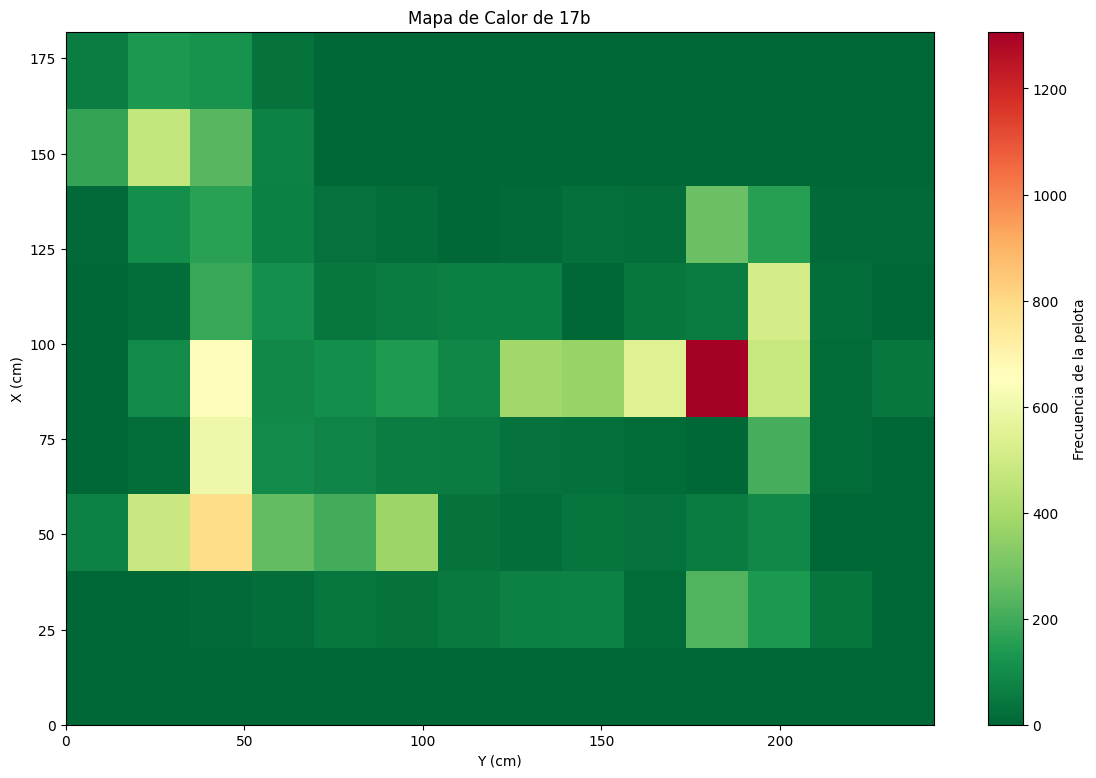

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 9))

# Crear el histograma 2D
plt.hist2d(
    df_robot_17b['y_canon'],
    df_robot_17b['x_canon'],
    bins=[14, 9], # Cantidad de cuadros en X y en Y
    range=[[0, 243], [0, 182]], # Fija los límites directamente en el cálculo
    cmap='RdYlGn_r' # Paleta de colores invertida (blanco para vacío, rojo/negro para lleno)
)

plt.colorbar(label='Frecuencia de la pelota')
plt.title('Mapa de Calor de 17b')
plt.xlabel('Y (cm)')
plt.ylabel('X (cm)')
plt.show()

## 4.2 Histogramas y boxplots de velocidad y distancia a la pelota

##